In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import openpyxl
import os


In [2]:
# Automatically detect Downloads folder
downloads = os.path.join(os.path.expanduser("~"), "Downloads")

# Build full paths for each file
dept_path = os.path.join(downloads, "departments.csv")
budget_path = os.path.join(downloads, "annual_budget.csv")
trans_path = os.path.join(downloads, "transactions.csv")

# Read the CSV files
df_codes = pd.read_csv(dept_path)
df_budget = pd.read_csv(budget_path)
df = pd.read_csv(trans_path)

In [3]:
df_codes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485 entries, 0 to 484
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Nominal Code   485 non-null    int64 
 1   Name           485 non-null    object
 2   NominalCode    485 non-null    object
 3   Category Name  485 non-null    object
 4   Category Code  485 non-null    object
 5   Category       485 non-null    object
 6   Type           485 non-null    object
 7   Budget         485 non-null    object
dtypes: int64(1), object(7)
memory usage: 30.4+ KB


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4295 entries, 0 to 4294
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   NominalCode  4295 non-null   object 
 1   Date         4295 non-null   object 
 2   Narrative    4295 non-null   object 
 3   Amount       4295 non-null   float64
dtypes: float64(1), object(3)
memory usage: 134.3+ KB


In [5]:

df_budget.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   NominalCode  232 non-null    object 
 1   1            231 non-null    float64
 2   2            228 non-null    float64
 3   3            229 non-null    float64
 4   4            228 non-null    float64
 5   5            228 non-null    float64
 6   6            228 non-null    float64
 7   7            228 non-null    float64
 8   8            228 non-null    float64
 9   9            231 non-null    float64
 10  10           231 non-null    float64
 11  11           231 non-null    float64
 12  12           228 non-null    float64
 13  Total        232 non-null    float64
dtypes: float64(13), object(1)
memory usage: 25.5+ KB


In [6]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
# df['Date'] = pd.to_datetime(df['Date'])

<div style="border:1px solid white; border-radius:6px; overflow:hidden;">
  <div style="background:#808080; color:white; padding:8px 12px; font-weight:bold; font-size:20px;">
    Arguments & Helper functions
     
  </div>
  <div style="background:#f009000; padding:12px; color: #808080">
   
  </div>
</div>


In [7]:
period_start = 1
period_end = 9
large_variance_diff = 1000 #large variances threshold
number_of_children = 350
# Debtor reports data (ToDo: Create a separate Excel file to store additional non‑transactional data needed for analysis)
debts = 4230 # from Deptors reports (Meals, Wraparound care, contracts)
depreciation = 35000
reserves = 50000

In [8]:
# format values to 100K and 100M format

def format_k(value):
    if value >= 1_000_000:
        return f"{value/1_000_000:.1f}M"
    elif value >= 1_000:
        return f"{value/1_000:.0f}K"
    elif value <= -1_000_000:
        return f"{value/1_000_000:.1f}M"
    elif value <= - 1_000:
        return f"{value/1_000:.0f}K"
    else:
        return str(int(value))

In [9]:
# helper to converts a date to financial period
def financial_period(date):
    month = date.month
    # September = 1, October = 2, ..., August = 12
    return ((month - 9) % 12) + 1   

In [10]:
# report for the period
def period_report(df, df_codes, period_start, period_end):
    df['Period'] = df['Date'].apply(financial_period)
    mask = df['Period'].between(period_start, period_end)
    period_df = df.loc[mask].reset_index(drop=True)
    period_df = period_df.merge(df_codes, on='NominalCode', how='left').fillna(0)
    return period_df

In [11]:
# sum amounts by Nominal codes
def sum_by_period(df_period):
    # group and sum
    actual_df = df_period.groupby('NominalCode')['Amount'].sum().reset_index()
    actual_df.columns = ['NominalCode', 'ActualPeriodTotal']
    return actual_df

In [12]:
# sum budget amounts between two periods
def sum_budget_period(df_budget, period_start, period_end):
    # Convert period numbers to strings to match column names
    period_cols = [str(p) for p in range(period_start, period_end + 1)]
    # Calculate the sum across selected periods
    df_budget['BudgetPeriodTotal'] = df_budget[period_cols].sum(axis=1)
    # Return NominalCode + the calculated total
    return df_budget[['NominalCode', 'BudgetPeriodTotal']]

In [13]:
# Period Variance report
def variance_report(df_period, df_budget_period, period_start, period_end):
    # Actuals
    actual_df = sum_by_period(df_period)
    actual_df = actual_df.reset_index(drop=True)
    actual_df.columns = ['NominalCode', 'ActualPeriodTotal']
    # Budget
    budget_sum = sum_budget_period(df_budget, period_start, period_end)
    # Merge
    result = budget_sum.merge(actual_df, on='NominalCode', how='outer').fillna(0)
    # Variance
    result['Variance'] = (result['ActualPeriodTotal'] - result['BudgetPeriodTotal']).round(2)
    return result


In [14]:
def sum_by_category(df, category_col, amount_col):
    """
    Groups a dataframe by a category column and sums the amounts column.
    Parameters:
    df (pd.DataFrame): input dataframe
    category_col (str): name of the category column
    amount_col (str): name of the amount column
    """
    result = (
        df.groupby(category_col)[amount_col]
          .sum()
          .reset_index()
          .rename(columns={amount_col: "TotalAmount"})
    )
    return result

<div style="border:1px solid white; border-radius:6px; overflow:hidden;">
  <div style="background:#808080; color:white; padding:8px 12px; font-weight:bold; font-size:20px;">
    Period data reports: actual, budget, actual vs. budget, summaries
     
  </div>
  <div style="background:#f009000; padding:12px; color: #808080">
    Variance analysis is the analysis of the difference between planned and actual numbers.The deviation can be favorable (better than expected) or unfavorable (worse than expected)
  </div>
</div>


In [15]:
# Full details report for the period ( with codes and categories)
df_period = period_report(df, df_codes, period_start, period_end)

In [16]:
# Cumulative actuals 
df_period_actuals = sum_by_period(df_period)

In [17]:
# Cumulative budget
df_period_budget = sum_budget_period(df_budget, period_start, period_end)

In [18]:
#Cumulative budget vs cumulative actuals 
df_period_variance = variance_report(df_period, df_budget, period_start, period_end)
df_period_variance.head(5)

,NominalCode,BudgetPeriodTotal,ActualPeriodTotal,Variance
0,4001 Rates Relief,-26910.00,-20930.00,5980.00
1,4010 Basic Entitlement Age Weighted Pupil Unit...,-3535209.00,-3535209.00,0.00
2,4011 Deprivation,-421408.53,-421408.80,-0.27
3,4012 Prior Attainment,-277584.03,-277583.85,0.18
4,4013 English as an Additional Language (EAL),-99567.00,-99565.20,1.80


In [19]:
#Cumulative budget vs cumulative actuals with Categories
df_variance = df_period_variance.merge(df_codes, on='NominalCode', how='left').fillna(0)
df_variance.head(5)

,NominalCode,BudgetPeriodTotal,ActualPeriodTotal,Variance,Nominal Code,Name,Category Name,Category Code,Category,Type,Budget
0,4001 Rates Relief,-26910.00,-20930.00,5980.00,4001.0,Rates Relief,Rates Relief (20%),IN04,IN04 Rates Relief (20%),Income,Rates relief
1,4010 Basic Entitlement Age Weighted Pupil Unit...,-3535209.00,-3535209.00,0.00,4010.0,Basic Entitlement Age Weighted Pupil Unit (AWPU),ESFA - School Allocation,IN01,IN01 ESFA - School Allocation,Income,Funding
2,4011 Deprivation,-421408.53,-421408.80,-0.27,4011.0,Deprivation,ESFA - School Allocation,IN01,IN01 ESFA - School Allocation,Income,Funding
3,4012 Prior Attainment,-277584.03,-277583.85,0.18,4012.0,Prior Attainment,ESFA - School Allocation,IN01,IN01 ESFA - School Allocation,Income,Funding
4,4013 English as an Additional Language (EAL),-99567.00,-99565.20,1.80,4013.0,English as an Additional Language (EAL),ESFA - School Allocation,IN01,IN01 ESFA - School Allocation,Income,Funding


In [20]:
#Cumulative budget vs cumulative actuals with Categories 
# (with budget and actual totals as absolute values)
df_variance_abs = df_variance.copy()
df_variance_abs.loc[:, 'ActualPeriodTotal'] = df_variance_abs['ActualPeriodTotal'].abs()
df_variance_abs.loc[:, 'BudgetPeriodTotal'] = df_variance_abs['BudgetPeriodTotal'].abs()


In [21]:
# Period report where Type = Expenses
df_expenses = df_variance_abs[df_variance_abs['Type'] == 'Expenses']
# Period report where Type = Income
df_income = df_variance_abs[df_variance_abs['Type'] == 'Income']

df_income.head(5)

,NominalCode,BudgetPeriodTotal,ActualPeriodTotal,Variance,Nominal Code,Name,Category Name,Category Code,Category,Type,Budget
0,4001 Rates Relief,26910.00,20930.00,5980.00,4001.0,Rates Relief,Rates Relief (20%),IN04,IN04 Rates Relief (20%),Income,Rates relief
1,4010 Basic Entitlement Age Weighted Pupil Unit...,3535209.00,3535209.00,0.00,4010.0,Basic Entitlement Age Weighted Pupil Unit (AWPU),ESFA - School Allocation,IN01,IN01 ESFA - School Allocation,Income,Funding
2,4011 Deprivation,421408.53,421408.80,-0.27,4011.0,Deprivation,ESFA - School Allocation,IN01,IN01 ESFA - School Allocation,Income,Funding
3,4012 Prior Attainment,277584.03,277583.85,0.18,4012.0,Prior Attainment,ESFA - School Allocation,IN01,IN01 ESFA - School Allocation,Income,Funding
4,4013 English as an Additional Language (EAL),99567.00,99565.20,1.80,4013.0,English as an Additional Language (EAL),ESFA - School Allocation,IN01,IN01 ESFA - School Allocation,Income,Funding


In [22]:
total_income_budget = - (
    df_variance[df_variance['Type'] == 'Income']
        .groupby('Type')['BudgetPeriodTotal']
        .sum()
        .loc['Income']
)
total_expenses_budget = (
    df_variance[df_variance['Type'] == 'Expenses']
        .groupby('Type')['BudgetPeriodTotal']
        .sum()
        .loc['Expenses']
)

total_income_actual = - (
    df_variance[df_variance['Type'] == 'Income']
        .groupby('Type')['ActualPeriodTotal']
        .sum()
        .loc['Income']
)

total_expenses_actual = (
    df_variance[df_variance['Type'] == 'Expenses']
        .groupby('Type')['ActualPeriodTotal']
        .sum()
        .loc['Expenses']
)

#print(f"total_income_budget: {total_income_budget:.2f}")
#print(f"total_income_actual: {total_income_actual:.2f}")
#print(f"total_expenses_budget: {total_expenses_budget:.2f}")
#print(f"total_expenses_actual: {total_expenses_actual:.2f}")

<div style="border:1px solid white; border-radius:6px; overflow:hidden;">
  <div style="background:#808080; color:white; padding:8px 12px; font-weight:bold; font-size:20px;">
    Budget Summary analysis
     
  </div>
  <div style="background:#f009000; padding:12px; color: #808080">
    
  </div>
</div>

In [23]:
# Total income (actual, budget, variance, variance percentage)
total_income_var = int(total_income_actual - total_income_budget)
total_income_var_pct = ((total_income_var/total_income_budget)*100).round(2)
print(f"Total Income (budget): {total_income_budget:.0f}")
print(f"Total Income (actual): {total_income_actual:.0f}")
print(f"Income Variance: {total_income_var}")
print(f"Income Variance (%): {total_income_var_pct}")

Total Income (budget): 7683320
Total Income (actual): 7798036
Income Variance: 114715
Income Variance (%): 1.49


In [24]:
# Total expenses (actual, budget, variance, variance percentage)
total_expense_var = int(total_expenses_actual - total_expenses_budget)
total_expense_var_pct = ((total_expense_var/total_expenses_budget)*100).round(2)
print(f"Total Expenses (budget): {total_expenses_budget:.0f}")
print(f"Total Expenses (actual): {total_expenses_actual:.0f}")
print(f"Expense Variance: {total_expense_var}")
print(f"Expense Variance (%): {total_expense_var_pct}")

Total Expenses (budget): 7607631
Total Expenses (actual): 7353221
Expense Variance: -254410
Expense Variance (%): -3.34


<div style="border:1px solid white; border-radius:6px; overflow:hidden;">
  <div style="background:#808080; color:white; padding:8px 12px; font-weight:bold; font-size:20px;">
    Income analysis
     
  </div>
  <div style="background:#f009000; padding:12px; color: #808080">
    
  </div>
</div>

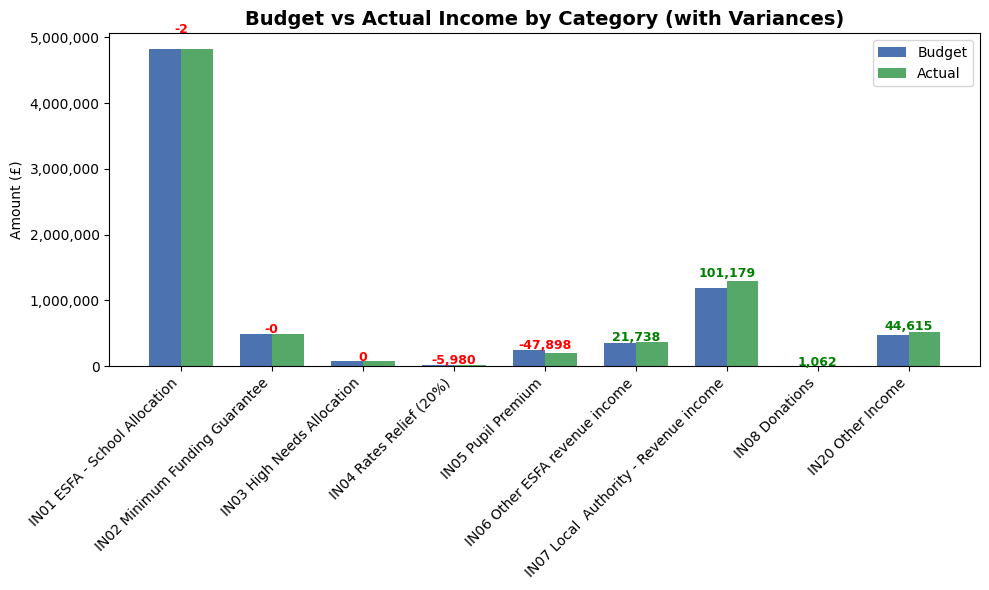

In [25]:
# ============================================================
# 1) INCOME — grouped by Category (Bar chart)
# ============================================================
category_summary_income = (
    df_income
             .groupby('Category')[['BudgetPeriodTotal', 'ActualPeriodTotal']]
             .sum()
             .reset_index()
             #.sort_values('ActualPeriodTotal', ascending=False)
)
# Prepare Data
categories = category_summary_income['Category']
budgets = category_summary_income['BudgetPeriodTotal']
actuals = category_summary_income['ActualPeriodTotal']
variance = actuals - budgets


x = np.arange(len(categories))
bar_width = 0.35

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Budget bars
#ax1.bar(x - bar_width/2, budgets, width=bar_width, label="Budget", color="#4C72B0")

# Actual bars
#ax1.bar(x + bar_width/2, actuals, width=bar_width, label="Actual", color="#55A868")

# Titles and labels
ax1.set_title("Budget vs Actual Income by Category (with Variances)", fontsize=14, fontweight="bold")
ax1.set_ylabel("Amount (£)")
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=45, ha='right')


# --- Variance labels above bars using bar heights ---
bars_budget = ax1.bar(x - bar_width/2, budgets, width=bar_width, label="Budget", color="#4C72B0")
bars_actual = ax1.bar(x + bar_width/2, actuals, width=bar_width, label="Actual", color="#55A868")

for i, v in enumerate(variance):
    colour = "green" if v > 0 else "red"   # overspend/unfavourable = red
    # y_pos = max(actuals[i], budgets[i]) + offset  # above tallest bar
     # Get the tallest bar at this x-position
    tallest_bar_height = max(bars_budget[i].get_height(), bars_actual[i].get_height())

    # Add a small offset above the tallest bar
    y_pos = tallest_bar_height + (tallest_bar_height * 0.05)
    ax1.text(
        x[i],
        y_pos,
        f"{v:,.0f}",
        color=colour,
        fontsize=9,
        fontweight="bold",
        ha="center"
    )
# Format y-axis with commas (e.g., 1,200,000)
ax1.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{int(x):,}")
)
ax1.legend()
plt.tight_layout()
plt.show()



In [26]:
# ========================
# Other Income breakdown
# ========================
other_income = (
    df_income[df_income['Category'] == 'IN20 Other Income']
             .groupby('NominalCode')[['BudgetPeriodTotal', 'ActualPeriodTotal']]
             .sum()
             .reset_index()
             .sort_values('ActualPeriodTotal', ascending=False)
)
other_income['Variance'] = other_income['ActualPeriodTotal'] - other_income['BudgetPeriodTotal']
other_income

,NominalCode,BudgetPeriodTotal,ActualPeriodTotal,Variance
12,4110 TEA TIME CLUB,291832.47,335651.17,43818.70
11,4110 BREAKFAST CLUB,53611.20,54315.15,703.95
13,4111 Afterschool Clubs,33092.28,41078.25,7985.97
14,4120 Nursery Income 3 Year olds,3750.03,29984.88,26234.85
7,4063 Lettings,15000.03,14820.00,-180.03
2,4052 Residential Trips,29999.97,12200.00,-17799.97
9,4100 SCHOOL LUNCH,4500.00,11652.12,7152.12
1,4051 TRIPS,3750.03,5270.50,1520.47
6,4062 Insurance RPA income,0.00,4860.00,4860.00
8,4066 Fundraising,3022.47,4029.97,1007.50


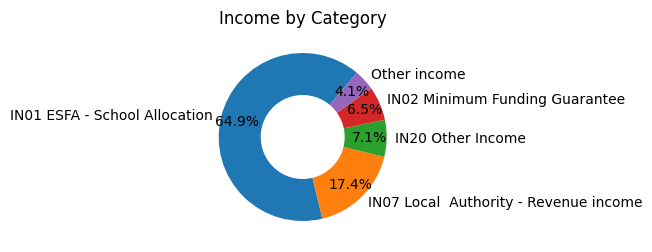

In [27]:
#-------------------------------------------------------------------------------
# INCOME - Gropued by Category (Percentage) (Donut)
#-------------------------------------------------------------------------------
income_by_cat = sum_by_category(df_income, 'Category', 'ActualPeriodTotal')

# Copy dataframe
df_inc = income_by_cat.copy()

# Calculate total and threshold
total_i = df_inc['TotalAmount'].sum()
threshold = 0.03 * total_i   # 3%

# Split into large and small categories
large_i = df_inc[df_inc['TotalAmount'] >= threshold]
small_i = df_inc[df_inc['TotalAmount'] < threshold]

# Combine small categories into "Other income"
other_sum = small_i['TotalAmount'].sum()

df_final_i = large_i.copy()
df_final_i.loc[len(df_final_i)] = ['Other income', other_sum]

# Sort for nicer plotting
df_final_i = df_final_i.sort_values('TotalAmount', ascending=False)

# Plot donut
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    df_final_i['TotalAmount'],
    labels=df_final_i['Category'],
    autopct='%1.1f%%',
    startangle=50,
    pctdistance=0.8
)

# Create donut hole
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
ax.add_artist(centre_circle)

# Donut hole
centre = plt.Circle((0,0), 0.30, fc='white')
ax.add_artist(centre)

ax.set_title('Income by Category')
plt.tight_layout()
plt.show()



In [28]:
# -------------------------------------------------------------
# INCOME: Variance report by category
# -------------------------------------------------------------
var_by_cat_income = (
    df_income
        .groupby('Category')[['BudgetPeriodTotal', 'ActualPeriodTotal', 'Variance']]
        .sum()
        .reset_index()
        .sort_values('ActualPeriodTotal', ascending = False)
)
var_by_cat_income


,Category,BudgetPeriodTotal,ActualPeriodTotal,Variance
0,IN01 ESFA - School Allocation,4819031.28,4819029.75,1.53
6,IN07 Local Authority - Revenue income,1194104.34,1295283.76,-101179.42
8,IN20 Other Income,482171.58,526786.56,-44614.98
1,IN02 Minimum Funding Guarantee,485877.78,485877.60,0.18
5,IN06 Other ESFA revenue income,347879.79,369618.05,-21738.26
4,IN05 Pupil Premium,243157.50,195260.00,47897.50
2,IN03 High Needs Allocation,81000.00,81000.00,0.00
3,IN04 Rates Relief (20%),26910.00,20930.00,5980.00
7,IN08 Donations,3187.62,4250.11,-1062.49


In [29]:
# Income: Favourable large variances
large_var_fav_income = df_variance_abs[(df_variance_abs['Variance'] < -large_variance_diff) & (df_variance_abs['Type'] == 'Income')]

large_var_fav_income[['NominalCode', 'BudgetPeriodTotal', 'ActualPeriodTotal', 'Variance']].sort_values('Variance', ascending=True)

,NominalCode,BudgetPeriodTotal,ActualPeriodTotal,Variance
14,4036 UPFSM,186519.78,251447.47,-64927.69
36,4110 TEA TIME CLUB,291832.47,335651.17,-43818.70
29,4070 Early Years funding - 2 Year olds,33976.53,68445.18,-34468.65
16,4038 National Insurance contributions (NICs) g...,88469.28,120802.42,-32333.14
38,4120 Nursery Income 3 Year olds,3750.03,29984.88,-26234.85
15,4037 Schools Budget Support Grant (SBSG),75031.47,92139.00,-17107.53
30,4071 SEN - High Needs,690000.03,702506.75,-12506.72
37,4111 Afterschool Clubs,33092.28,41078.25,-7985.97
32,4073 LBWF OTHER revenue income,15000.03,22482.00,-7481.97
33,4100 SCHOOL LUNCH,4500.00,11652.12,-7152.12


In [30]:
# Income: Unfavourable large variances
large_var_unfav_income = df_variance_abs[(df_variance_abs['Variance'] > large_variance_diff) & (df_variance_abs['Type'] == 'Income')]

large_var_unfav_income[['NominalCode', 'BudgetPeriodTotal', 'ActualPeriodTotal', 'Variance']].sort_values('Variance', ascending=True)

,NominalCode,BudgetPeriodTotal,ActualPeriodTotal,Variance
42,4160 School Uniform Income (Parents),1500.03,72.25,1427.78
22,4061 OTHER INCOME (business),4500.00,903.28,3596.72
31,4072 SENIF funding,33750.00,29586.31,4163.69
0,4001 Rates Relief,26910.00,20930.00,5980.00
21,4060 Absence insurance income,11250.00,3570.00,7680.00
28,4069 Early Years funding - 3 & 4 Year olds,234857.97,220816.05,14041.92
20,4052 Residential Trips,29999.97,12200.00,17799.97
40,4122 Nursery Income 2 Year olds,21930.75,2843.33,19087.42
13,4035 UIFSM FUNDING,149761.53,110648.00,39113.53
10,4020 Pupil Premium,243157.50,195260.00,47897.50


<div style="border:1px solid white; border-radius:6px; overflow:hidden;">
  <div style="background:#808080; color:white; padding:8px 12px; font-weight:bold; font-size:20px;">
    Expenditure Analysis
     
  </div>
  <div style="background:#f009000; padding:12px; color: #808080">
      
  </div>
</div>

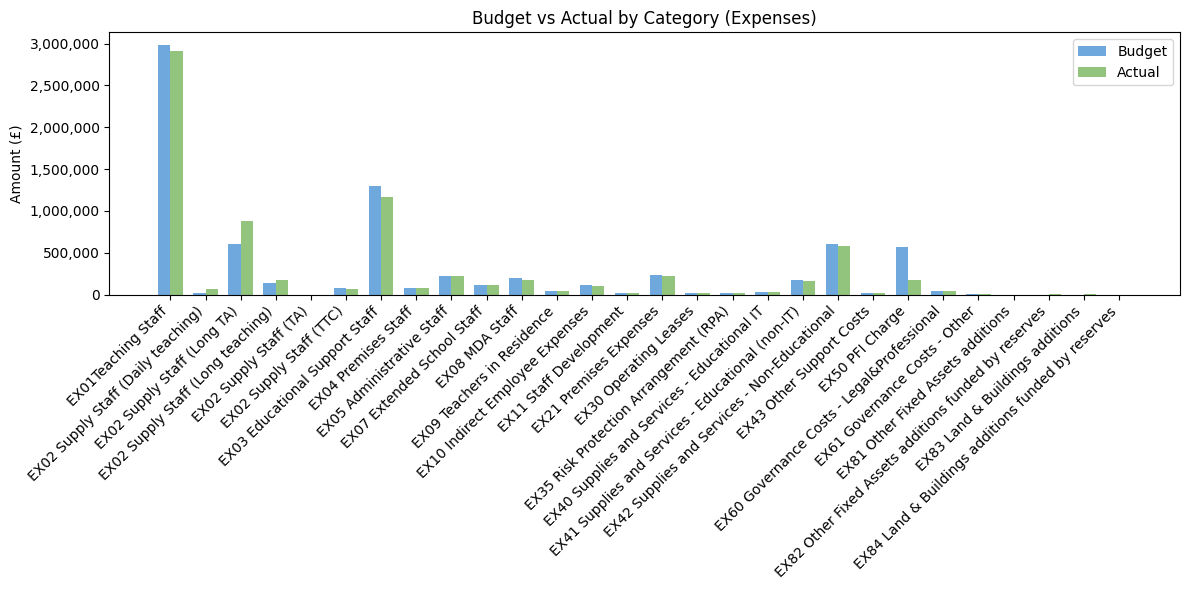

In [31]:
# ============================================================
# 1) INCOME — grouped by Category (Bar chart)
# ============================================================
category_summary_exp = (
    df_expenses.groupby('Category')[['BudgetPeriodTotal', 'ActualPeriodTotal']]
             .sum()
             .reset_index()
             #.sort_values('ActualPeriodTotal', ascending=False)
)
# Prepare Data
categories = category_summary_exp['Category']
budgets = category_summary_exp['BudgetPeriodTotal']
actuals = category_summary_exp['ActualPeriodTotal']

x = np.arange(len(categories))
width = 0.35

# Plot
plt.figure(figsize=(12, 6))

plt.bar(x - width/2, budgets, width, label='Budget', color='#6fa8dc')
plt.bar(x + width/2, actuals, width, label='Actual', color='#93c47d')

# Fix y-axis to show actual values (no scientific notation)
# plt.ticklabel_format(style='plain', axis='y')

# Format y-axis with commas (e.g., 500,000)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{int(x):,}")
)

plt.xticks(x, categories, rotation=45, ha='right')
plt.ylabel('Amount (£)')
plt.title('Budget vs Actual by Category (Expenses)')
plt.legend()

plt.tight_layout()
plt.show()



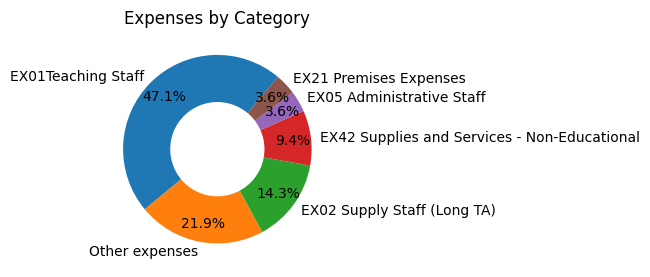

In [32]:
#-------------------------------------------------------------------------------
# EXPENSES - Gropued by Category (Percentage) (Donut)
#-------------------------------------------------------------------------------
exp_by_cat = sum_by_category(df_expenses, 'Category', 'ActualPeriodTotal')

# Copy dataframe
df_exp = exp_by_cat.copy()

# Calculate total and threshold
total = df_exp['TotalAmount'].sum()
threshold = 0.03 * total   # 3%

# Split into large and small categories
large = df_exp[df_exp['TotalAmount'] >= threshold]
small = df_exp[df_exp['TotalAmount'] < threshold]

# Combine small categories into "Other income"
other_sum = small['TotalAmount'].sum()

df_final = large.copy()
df_final.loc[len(df_final)] = ['Other expenses', other_sum]

# Sort for nicer plotting
df_final = df_final.sort_values('TotalAmount', ascending=False)

# Plot donut
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    df_final['TotalAmount'],
    labels=df_final['Category'],
    autopct='%1.1f%%',
    startangle=50,
    pctdistance=0.8
)

# Create donut hole
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
ax.add_artist(centre_circle)

# Donut hole
centre = plt.Circle((0,0), 0.30, fc='white')
ax.add_artist(centre)

ax.set_title('Expenses by Category')
plt.tight_layout()
plt.show()



In [33]:
# -------------------------------------------------------------
# EXPENSES: Variance report by category
# -------------------------------------------------------------
var_by_cat_exp = (
    df_expenses
        .groupby('Category')[['BudgetPeriodTotal', 'ActualPeriodTotal', 'Variance']]
        .sum()
        .reset_index()
        .sort_values('ActualPeriodTotal', ascending = False)
)
var_by_cat_exp


,Category,BudgetPeriodTotal,ActualPeriodTotal,Variance
0,EX01Teaching Staff,2985786.72,2913487.31,-72299.41
6,EX03 Educational Support Staff,1300476.78,1170891.76,-129585.02
2,EX02 Supply Staff (Long TA),609388.47,884888.96,275500.49
19,EX42 Supplies and Services - Non-Educational,605990.84,582364.21,-23626.63
8,EX05 Administrative Staff,217487.25,224896.62,7409.37
14,EX21 Premises Expenses,239011.56,223691.97,-15319.59
3,EX02 Supply Staff (Long teaching),141521.22,179274.98,37753.76
10,EX08 MDA Staff,191863.53,177617.45,-14246.08
21,EX50 PFI Charge,570040.66,172182.32,-397858.34
18,EX41 Supplies and Services - Educational (non-IT),169739.73,164794.86,-4944.87


In [34]:
# Expenses: Favourable large variances
large_var_fav_exp = df_variance_abs[(df_variance_abs['Variance'] < -large_variance_diff) & (df_variance_abs['Type'] == 'Expenses')]

large_var_fav_exp[['NominalCode', 'BudgetPeriodTotal', 'ActualPeriodTotal', 'Variance']].sort_values('Variance', ascending=True)

,NominalCode,BudgetPeriodTotal,ActualPeriodTotal,Variance
44,5010 Teaching staff - Pay,2985786.72,2201339.82,-784446.90
54,5110 Educational support - Pay,1300476.78,932119.59,-368357.19
218,7546 PFI Affordability,275308.00,78180.67,-197127.33
220,7548 PFI Hillyfield Contribution,282744.66,90920.66,-191824.00
243,7700 CATERING COSTS Hill+ Park,432939.78,372780.06,-60159.72
57,5210 MDA Staff - Pay,191863.53,142595.98,-49267.55
60,5310 Administrative Staff - Pay,217487.25,189612.28,-27874.97
52,5027 Long term Caretaking,26603.28,10491.00,-16112.28
68,5610 Extended School - Pay,107819.28,93681.61,-14137.67
223,7551 Audit fees,13169.97,30.00,-13139.97


In [35]:
# Expenses: Unfavourable large variances
large_var_unfav_exp = df_variance_abs[(df_variance_abs['Variance'] > large_variance_diff) & (df_variance_abs['Type'] == 'Expenses')]

large_var_unfav_exp[['NominalCode', 'BudgetPeriodTotal', 'ActualPeriodTotal', 'Variance']].sort_values('Variance', ascending=True)

,NominalCode,BudgetPeriodTotal,ActualPeriodTotal,Variance
82,6022 Annual Lift Check,246.78,1297.47,1050.69
197,7150 First Aid,1043.82,2101.51,1057.69
216,7541 Governors Clerking charges,2447.28,3540.00,1092.72
261,9012 National College,3143.97,4237.20,1093.23
89,"6029 Medical, Sanitary & Nappy Bins",3360.78,4480.99,1120.21
206,7528 Parent Pay Annual Licence,0.00,1206.00,1206.00
228,7558 Mercer's Acturial,0.00,1365.00,1365.00
107,6117 ACE Security,4316.22,5754.94,1438.72
200,7380 Payments service fee,2475.00,3928.01,1453.01
196,7150 Assessment Park,1312.47,2930.20,1617.73


<div style="border:1px solid white; border-radius:6px; overflow:hidden;">
  <div style="background:#808080; color:white; padding:8px 12px; font-weight:bold; font-size:20px;">
    Expenses: Trend & Pattern analysis
     
  </div>
  <div style="background:#f009000; padding:12px; color: #808080">
    Monthly spending trends. Line charts showing seasonal patterns 
  </div>
</div>

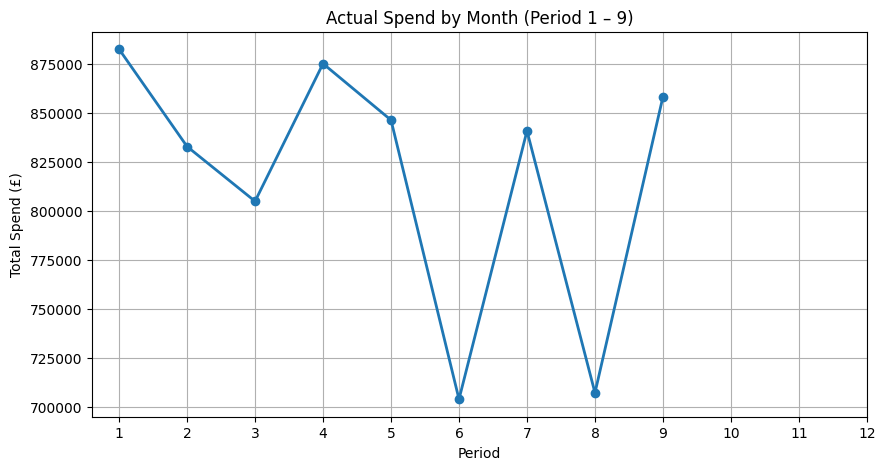

In [36]:
# --------------------------------------------------------
# EXPENSES: Line Chart — Actual Spend by Month
# --------------------------------------------------------

# Ensure Period is sorted
df_exp = df_period[df_period['Type'] == 'Expenses']
df_sorted = df_exp.sort_values("Period")

# Aggregate spend by month/period
monthly_spend = df_sorted.groupby("Period")["Amount"].sum().reset_index()

# Plot
plt.figure(figsize=(10,5))
plt.plot(monthly_spend["Period"], monthly_spend["Amount"], marker='o', linewidth=2)

plt.title(f"Actual Spend by Month (Period {period_start} – {period_end})")
plt.xlabel("Period")
plt.ylabel("Total Spend (£)")
plt.grid(True)
plt.xticks(range(1, 13))

plt.show()

<Figure size 1400x700 with 0 Axes>

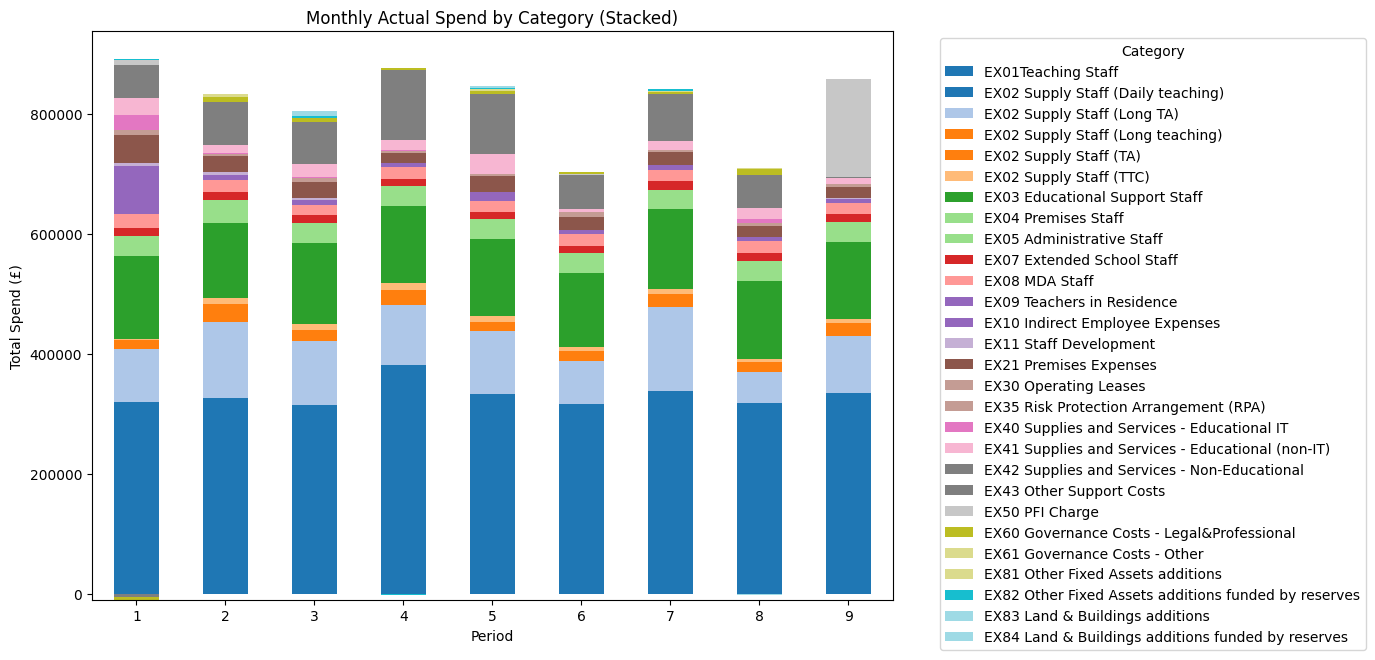

In [37]:
# --------------------------------------------------------------------
#  EXPENSES: Stacked Bar Chart — Actual Spend by Month by Category
# -------------------------------------------------------------------

# Aggregate spend by Period and Category
monthly_cat = (
    df_exp.groupby(["Period", "Category"])["Amount"]
      .sum()
      .reset_index()
)

pivot_data = monthly_cat.pivot(index="Period", columns="Category", values="Amount").fillna(0)

plt.figure(figsize=(14,7))

pivot_data.plot(
    kind="bar",    #'bar'
    stacked=True,
    figsize=(14,7),
    colormap="tab20"
)

plt.title("Monthly Actual Spend by Category (Stacked)")
plt.xlabel("Period")
plt.ylabel("Total Spend (£)")
plt.xticks(rotation=0)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.show()

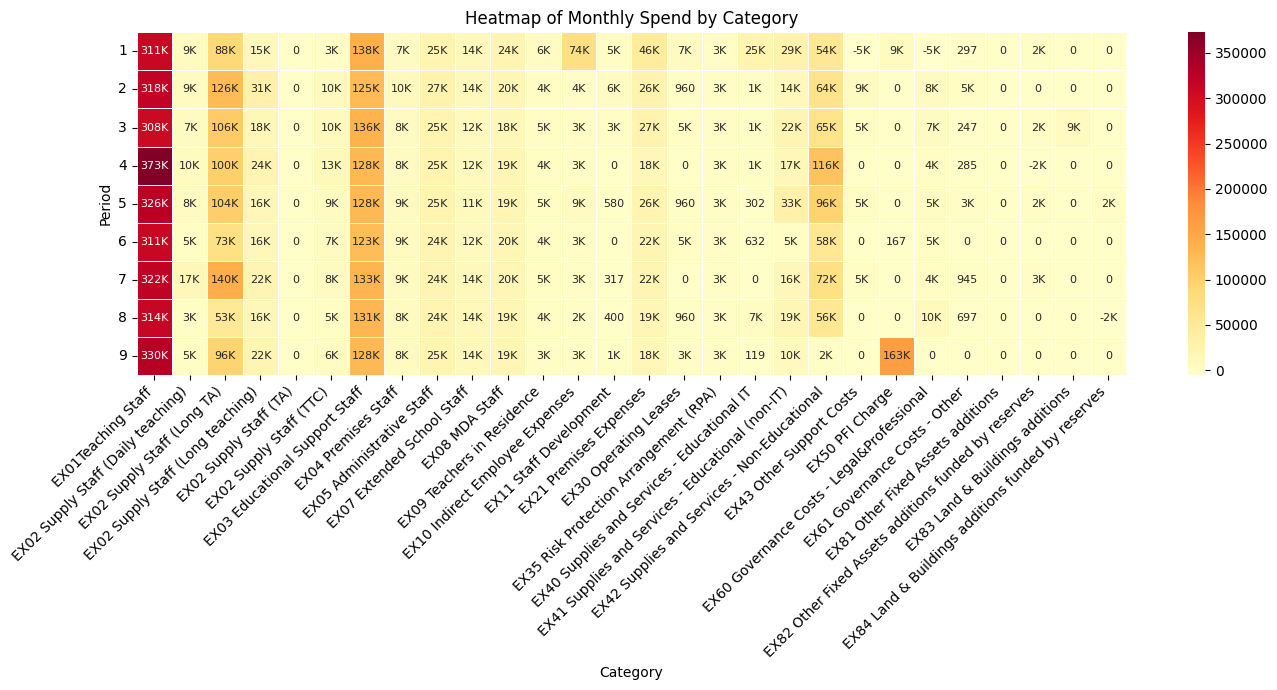

In [47]:
# --------------------------------------------------------------------
#  EXPENSES: Heatmap — Actual Spend by Month by Category
# -------------------------------------------------------------------


plt.figure(figsize=(14,7))

sns.heatmap(
    pivot_data,  #from line [41]
    annot=pivot_data.map(format_k),
    annot_kws={"size": 8},   # font size
    cmap="YlOrRd",
    linewidths=0.5,
    #annot=True,        # show values
    fmt = "" #    fmt=".0f" # no decimals
)

plt.title("Heatmap of Monthly Spend by Category")
plt.xlabel("Category")
plt.ylabel("Period")
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


In [39]:
period_va = variance_report(df_period, df_budget, period_start, period_end)
period_va.head(5)

,NominalCode,BudgetPeriodTotal,ActualPeriodTotal,Variance
0,4001 Rates Relief,-26910.00,-20930.00,5980.00
1,4010 Basic Entitlement Age Weighted Pupil Unit...,-3535209.00,-3535209.00,0.00
2,4011 Deprivation,-421408.53,-421408.80,-0.27
3,4012 Prior Attainment,-277584.03,-277583.85,0.18
4,4013 English as an Additional Language (EAL),-99567.00,-99565.20,1.80


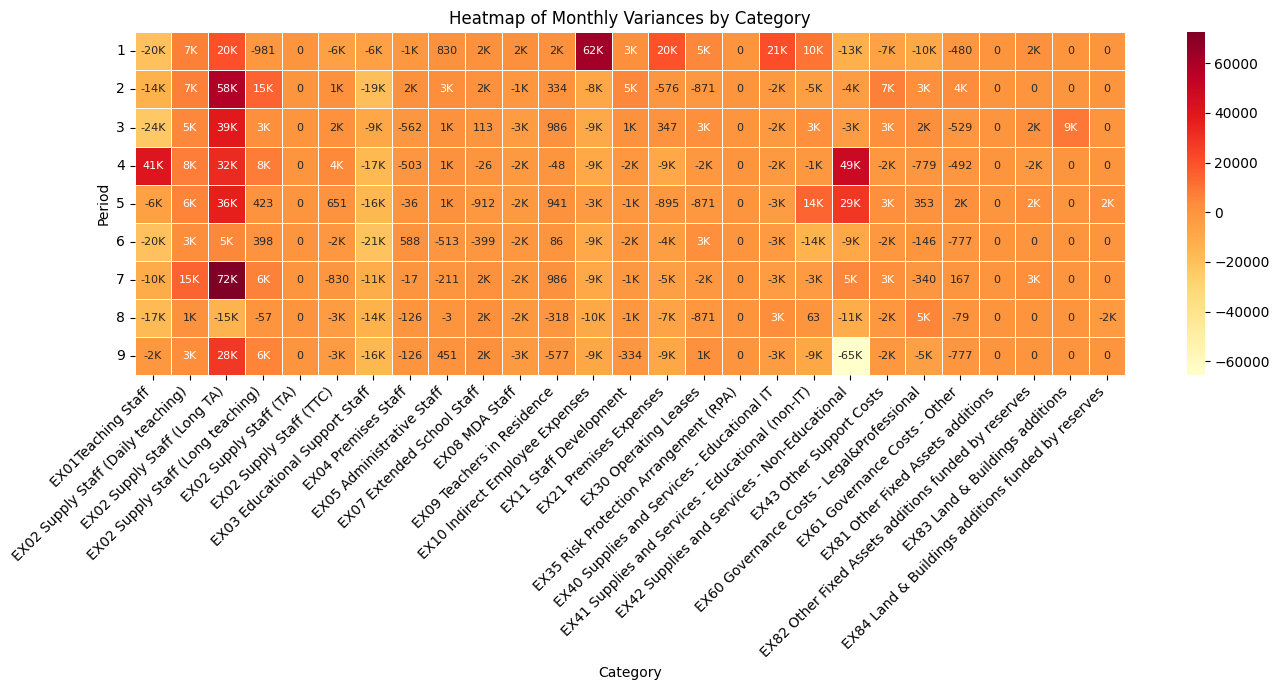

In [48]:
# --------------------------------------------------------------------
#  EXPENSES: Heatmap — Variance by Category
# -------------------------------------------------------------------

# Function to calculayte variance for eac period
def variance_by_period(df, budget):
    results = []

    for p in range(period_start, period_end +1): # periods 
        df_by_period = period_report(df, df_codes, p, p)
        df_p = variance_report(df_by_period, budget, p, p)
        df_p['Period'] = p
        results.append(df_p)

    return pd.concat(results, ignore_index=True)

df_exp_var_by_p = variance_by_period(df_period, df_budget)
df_exp_var_by_p = df_exp_var_by_p.merge(df_codes, on='NominalCode', how='left').fillna(0)
df_exp_var_by_p_by_cat = (
  df_exp_var_by_p[(df_exp_var_by_p['Type'] == 'Expenses') & (df_exp_var_by_p['Category'] != 'EX50 PFI Charge')]
      .groupby(['Period','Category'])['Variance'].sum()
      .reset_index()
)

pivot_var = df_exp_var_by_p_by_cat.pivot(index="Period", columns="Category", values="Variance").fillna(0)
plt.figure(figsize=(14,7))

sns.heatmap(
    pivot_var,
    annot=pivot_var.map(format_k),
    annot_kws={"size": 8},   # font size
    cmap="YlOrRd",
    linewidths=0.5,
    # annot=True,        # show values
    fmt= ""           #".0f"          # no decimals
)

plt.title("Heatmap of Monthly Variances by Category")
plt.xlabel("Category")
plt.ylabel("Period")
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()



<div style="border:1px solid white; border-radius:6px; overflow:hidden;">
  <div style="background:#808080; color:white; padding:8px 12px; font-weight:bold; font-size:20px;">
    Dashboard  
  </div>
  <div style="background:#f009000; padding:12px; color: #808080">   
  </div>
</div>

In [41]:
categories = category_summary_exp['Category']
budgets = category_summary_exp['BudgetPeriodTotal']
actuals = category_summary_exp['ActualPeriodTotal']


In [42]:
period_plus = period_end +1 
df_budget_future = sum_budget_period(df_budget, period_plus, 12)
df_budget_future =  - df_budget_future['BudgetPeriodTotal'].sum()
df_budget_future 


np.float64(-69045.59999999963)

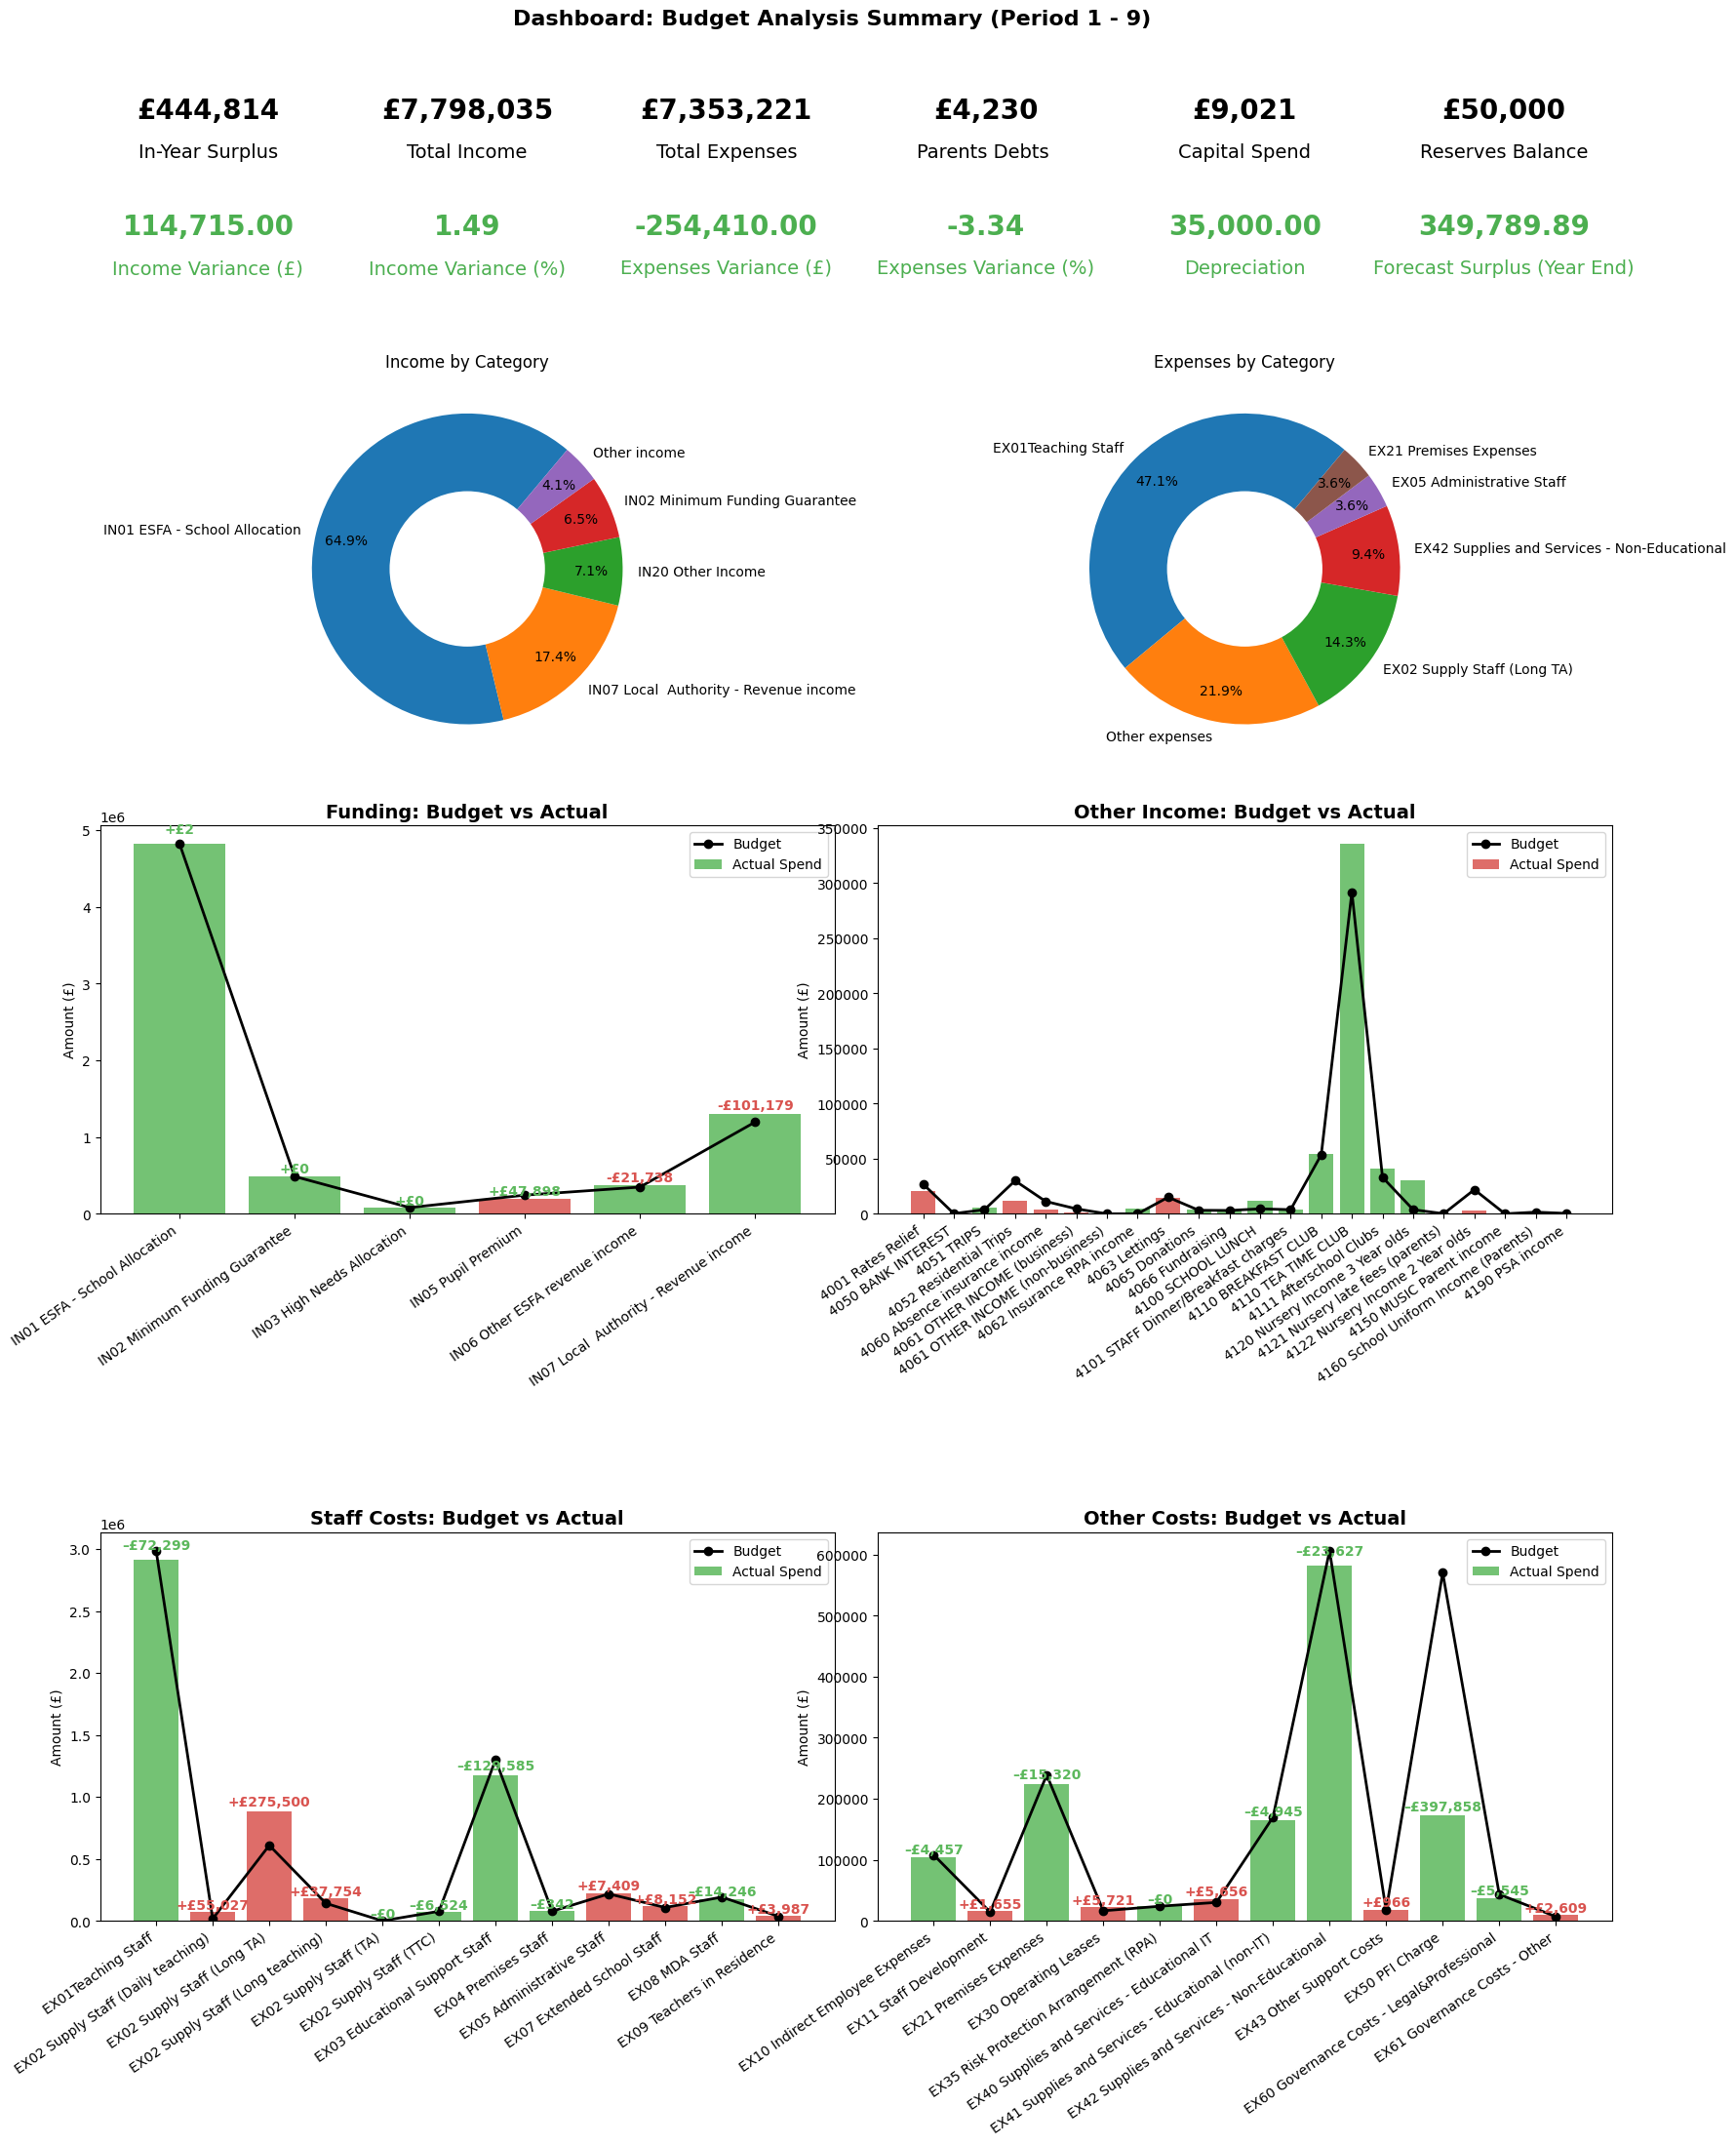

In [43]:
# ==========================
# Dashboard
# ==========================

fig = plt.figure(figsize=(20, 24))
#grid = (6, 6)

# set fixed size of the grids
gs = plt.GridSpec(
    5, 6,
    figure=fig,
    height_ratios=[0.5, 1, 1, 0.5, 1]   # KPI row taller
)

fig.text(
    0.5, 0.92,
    f"Dashboard: Budget Analysis Summary (Period {period_start} - {period_end})",
    ha='center',
    fontsize=16,
    fontweight='bold'
)


# ===========================
# TOP KPIs CARDS
# ===========================
year_surplus = - int(df_variance['ActualPeriodTotal'].sum())
total_income = int(df_income['ActualPeriodTotal'].sum())
total_exp = int(df_expenses['ActualPeriodTotal'].sum())
if year_surplus > 0:
    surplus_label = "In-Year Surplus"
else:
   surplus_label = "In-Year Deficit"

# debts = see line [8]  from Deptors reports (Meals, Wraparound care, contracts, trips)
capital =  df_variance[df_variance['NominalCode'] == '8020 CIF Funding Expenditure AirCond/Overheating/Roof/Windows']['ActualPeriodTotal'].sum()


raw_values = [year_surplus, total_income, total_exp, debts, capital, reserves]
kpi_values = [f"£{v:,.0f}" for v in raw_values]
kpi_labels = [
    surplus_label,
    "Total Income",
    "Total Expenses",
    "Parents Debts ",
    "Capital Spend",
    "Reserves Balance"
]

ye_progected_balance = df_budget_future + year_surplus - depreciation + capital 
if ye_progected_balance > 0:
    ye_progected_balance_label = "Forecast Surplus (Year End)"
else:
   ye_progected_balance_label = "Forecast Deficit (Year End)"
raw_values2 = [total_income_var, total_income_var_pct, total_expense_var, total_expense_var_pct, depreciation, ye_progected_balance]
kpi_values2 = [f"{v:,.2f}" for v in raw_values2]
kpi_labels2 = [
    "Income Variance (£)",
    "Income Variance (%)",
    "Expenses Variance (£)",
    "Expenses Variance (%)",
    "Depreciation",
    ye_progected_balance_label
]

for i in range(6):
    #ax = plt.subplot2grid(grid, (0, i))
    ax = ax = fig.add_subplot(gs[0, i])
    ax.axis('off')
    ax.text(0.5, 1.0, kpi_values[i], ha='center', fontsize=20, fontweight='bold')
    ax.text(0.5, 0.8, kpi_labels[i], ha='center', fontsize=14)

for i in range(6):
    #ax = plt.subplot2grid(grid, (0, i))
    ax = fig.add_subplot(gs[0, i])
    ax.axis('off')
    ax.text(0.5, 0.4, kpi_values2[i], ha='center', fontsize=20, fontweight='bold', color= "#4CAF50")
    ax.text(0.5, 0.2, kpi_labels2[i], ha='center', fontsize=14, color= "#4CAF50" )
# =====================================
# Budget vs Actual (Staff Costs) (ax1) 
# =====================================
staff_summary = df_expenses[df_expenses['Budget'] == 'Staff costs']
staff_summary = (
    staff_summary.groupby('Category')[['BudgetPeriodTotal', 'ActualPeriodTotal']]
             .sum()
             .reset_index()
             #.sort_values('ActualPeriodTotal', ascending=False)
)

ax1 = fig.add_subplot(gs[4, 0:3])

# Data from line [36]
categories_s = staff_summary['Category']
budgets_s = staff_summary['BudgetPeriodTotal']
actuals_s = staff_summary['ActualPeriodTotal']

cost_centres_s = categories_s.to_list()
budget_s = budgets_s.to_numpy()
actual_s = actuals_s.to_numpy()


variance_s = actual_s - budget_s   # + = overspend, - = underspend

# Colours: red for overspend, green for underspend
colors = ["#d9534f" if v > 0 else "#5cb85c" for v in variance_s]

# Bars: Actual spend
bars = ax1.bar(cost_centres_s, actual_s, color=colors, alpha=0.85, label="Actual Spend")

# Line: Budget
ax1.plot(cost_centres_s, budget_s, color="black", linewidth=2, marker="o", label="Budget")

# Variance labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    label = f"+£{variance_s[i]:,.0f}" if variance_s[i] > 0 else f"–£{abs(variance_s[i]):,.0f}"
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + (height * 0.02),
        label,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#d9534f" if variance_s[i] > 0 else "#5cb85c"
    )

# Titles and labels
ax1.set_title("Staff Costs: Budget vs Actual", fontsize=14, fontweight="bold")
ax1.set_ylabel("Amount (£)")
ax1.set_xticks(range(len(cost_centres_s)))
ax1.set_xticklabels(cost_centres_s, rotation=35, ha='right')
ax1.legend()

# ============================
# Placeholder for ax2
# ============================

ax2 = fig.add_subplot(gs[4, 3:6])

other_exp_summary = df_expenses[df_expenses['Budget'] == 'Expenses']
other_exp_summary = (
    other_exp_summary.groupby('Category')[['BudgetPeriodTotal', 'ActualPeriodTotal']]
             .sum()
             .reset_index()
             #.sort_values('ActualPeriodTotal', ascending=False)
)

# Data 
categories_e = other_exp_summary['Category']
budgets_e = other_exp_summary['BudgetPeriodTotal']
actuals_e = other_exp_summary['ActualPeriodTotal']

cost_centres_e = categories_e.to_list()
budget_e = budgets_e.to_numpy()
actual_e = actuals_e.to_numpy()

variance_e = actual_e - budget_e   # + = overspend, - = underspend

# Colours: red for overspend, green for underspend
colors = ["#d9534f" if v > 0 else "#5cb85c" for v in variance_e]

# Bars: Actual spend
bars = ax2.bar(cost_centres_e, actual_e, color=colors, alpha=0.85, label="Actual Spend")

# Line: Budget
ax2.plot(cost_centres_e, budget_e, color="black", linewidth=2, marker="o", label="Budget")

# Variance labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    label = f"+£{variance_e[i]:,.0f}" if variance_e[i] > 0 else f"–£{abs(variance_e[i]):,.0f}"
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        height + (height * 0.02),
        label,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#d9534f" if variance_e[i] > 0 else "#5cb85c"
    )

# Titles and labels
ax2.set_title("Other Costs: Budget vs Actual", fontsize=14, fontweight="bold")
ax2.set_ylabel("Amount (£)")
ax2.set_xticks(range(len(cost_centres_e)))
ax2.set_xticklabels(cost_centres_e, rotation=35, ha='right')
ax2.legend()

# ============================
# Income by Category (%, Donut)
# ============================

# Plot donut
ax3 = fig.add_subplot(gs[1, 0:3])

wedges, texts, autotexts = ax3.pie(
    df_final_i['TotalAmount'],
    labels=df_final_i['Category'],
    autopct='%1.1f%%',
    startangle=50,
    pctdistance=0.8
)

# Create donut hole
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
ax3.add_artist(centre_circle)

# Donut hole
centre = plt.Circle((0,0), 0.30, fc='white')
ax3.add_artist(centre)

ax3.set_title('Income by Category')

# ============================
# ax4 Expenses by Category (%, Donut)
# ============================

ax4 = fig.add_subplot(gs[1, 3:6])

# Plot donut
wedges, texts, autotexts = ax4.pie(
    df_final['TotalAmount'],
    labels=df_final['Category'],
    autopct='%1.1f%%',
    startangle=50,
    pctdistance=0.8
)

# Create donut hole
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
ax4.add_artist(centre_circle)

# Donut hole
centre = plt.Circle((0,0), 0.30, fc='white')
ax4.add_artist(centre)

ax4.set_title('Expenses by Category')

# ============================
# ax5 Income by Category (Funding)
# ============================
funding_summary = df_income[df_income['Budget'] == 'Funding']
funding_summary = (
    funding_summary.groupby('Category')[['BudgetPeriodTotal', 'ActualPeriodTotal']]
             .sum()
             .reset_index()
             #.sort_values('ActualPeriodTotal', ascending=False)
)

ax5 = fig.add_subplot(gs[2, 0:3])

# Data 
categories_f = funding_summary['Category']
budgets_f = funding_summary['BudgetPeriodTotal']
actuals_f = funding_summary['ActualPeriodTotal']

cost_centres_f = categories_f.to_list()
budget_f = budgets_f.to_numpy()
actual_f = actuals_f.to_numpy()

variance_f = actual_f - budget_f   # + = overspend, - = underspend

# Colours: red for overspend, green for underspend
colors = ["#d9534f" if v < -100 else "#5cb85c" for v in variance_f]

# Bars: Actual spend
bars = ax5.bar(cost_centres_f, actual_f, color=colors, alpha=0.85, label="Actual Spend")

# Line: Budget
ax5.plot(cost_centres_f, budget_f, color="black", linewidth=2, marker="o", label="Budget")

# Variance labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    label = f"-£{variance_f[i]:,.0f}" if variance_f[i] > 0 else f"+£{abs(variance_f[i]):,.0f}"
    ax5.text(
        bar.get_x() + bar.get_width()/2,
        height + (height * 0.02),
        label,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#d9534f" if variance_f[i] > 0 else "#5cb85c"
    )

# Titles and labels
ax5.set_title("Funding: Budget vs Actual", fontsize=14, fontweight="bold")
ax5.set_ylabel("Amount (£)")
ax5.set_xticks(range(len(cost_centres_f)))
ax5.set_xticklabels(cost_centres_f, rotation=35, ha='right')
ax5.legend()

# ============================
# ax6 Income by Category (Other)
# ============================
other_summary = df_income[df_income['Budget'] != 'Funding']
other_summary = (
    other_summary.groupby('NominalCode')[['BudgetPeriodTotal', 'ActualPeriodTotal']]
             .sum()
             .reset_index()
             #.sort_values('ActualPeriodTotal', ascending=False)
)

ax6 = fig.add_subplot(gs[2, 3:6])

# Data 
categories_o = other_summary['NominalCode']
budgets_o = other_summary['BudgetPeriodTotal']
actuals_o = other_summary['ActualPeriodTotal']

cost_centres_o = categories_o.to_list()
budget_o = budgets_o.to_numpy()
actual_o = actuals_o.to_numpy()

variance_o = actual_o - budget_o   # + = overspend, - = underspend

# Colours: red for overspend, green for underspend
colors = ["#d9534f" if v < -100 else "#5cb85c" for v in variance_o]

# Bars: Actual spend
bars = ax6.bar(cost_centres_o, actual_o, color=colors, alpha=0.85, label="Actual Spend")

# Line: Budget
ax6.plot(cost_centres_o, budget_o, color="black", linewidth=2, marker="o", label="Budget")

# Titles and labels
ax6.set_title("Other Income: Budget vs Actual", fontsize=14, fontweight="bold")
ax6.set_ylabel("Amount (£)")
ax6.set_xticks(range(len(cost_centres_o)))
ax6.set_xticklabels(cost_centres_o, rotation=35, ha='right')
ax6.legend()

#plt.tight_layout()
plt.show()



In [44]:
df_period_variance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   NominalCode        274 non-null    object 
 1   BudgetPeriodTotal  274 non-null    float64
 2   ActualPeriodTotal  274 non-null    float64
 3   Variance           274 non-null    float64
dtypes: float64(3), object(1)
memory usage: 8.7+ KB


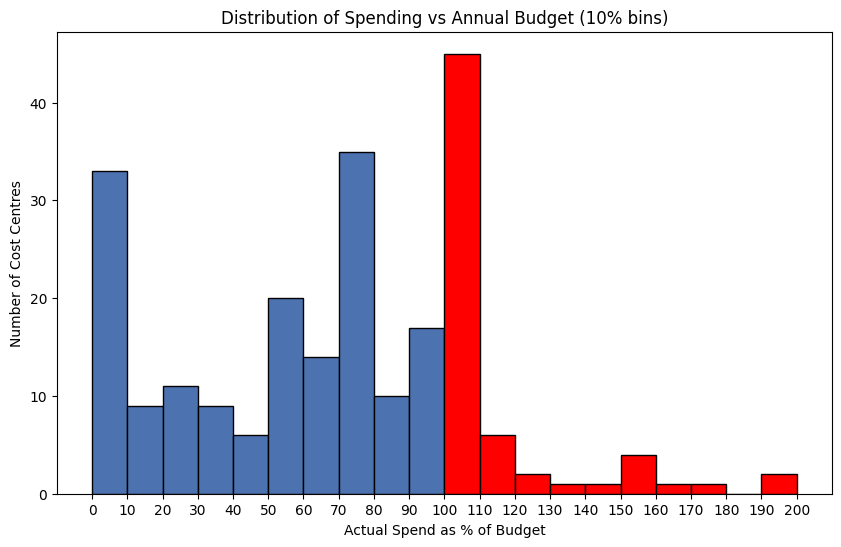

In [45]:
# Distribution of Spending vs Annual Budget (10% bins)
# Assuming your dataframe has columns: 'Budget', 'Actual'
df_ratio= df_period_variance.copy()
df_ratio = df_ratio.merge(df_budget, on='NominalCode', how='left').fillna(0)
df_ratio['SpendRatio'] = (df_ratio['ActualPeriodTotal'] / df_ratio['Total']) * 100

# Define 10% bins
bins = np.arange(0, 200, 10)  # 0–100%
bins = np.append(bins, 200)   # extra bin for overspend

plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(df_ratio['SpendRatio'], bins=bins, edgecolor='black')

# Colour overspend bin red
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge >= 100:
        patch.set_facecolor('red')
    else:
        patch.set_facecolor('#4C72B0')

plt.title("Distribution of Spending vs Annual Budget (10% bins)")
plt.xlabel("Actual Spend as % of Budget")
plt.ylabel("Number of Cost Centres")
plt.xticks(bins)

plt.show()

In [46]:
# EXPORT TO EXCEL
# Step 1. Automatically detect Downloads folder
downloads = os.path.join(os.path.expanduser("~"), "Downloads")

# Step 2. Base filename
base_name = 'Budget period Report'
extension = '.xlsx'

# Step 3. Original file name
filename = f"{base_name}{extension}"
full_path = os.path.join(downloads, filename)

# Step 4. Check if file exists and increment if needed
counter = 1
while os.path.exists(full_path):
    filename = f"{base_name}({counter}){extension}"
    full_path = os.path.join(downloads, filename)
    counter += 1

# Step 5. Export to Excel
with pd.ExcelWriter(full_path, engine='openpyxl') as writer:
    large_var_fav_income.to_excel(writer, sheet_name="Income variance favourable", index=False)
    large_var_unfav_income.to_excel(writer, sheet_name="Income variance unfavourable", index=False)
    large_var_fav_exp.to_excel(writer, sheet_name="Expense variance favourable", index=False)
    large_var_unfav_exp.to_excel(writer, sheet_name="Expense variance unfavourable", index=False)
    df_variance.to_excel(writer, sheet_name="All Variances", index=False)

print(f"Report saved to: {full_path}")

Report saved to: C:\Users\anzel\Downloads\Budget period Report.xlsx
